In [2]:
#IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
#LOAD DATASET
df = pd.read_csv("/content/mental_health_social_media_dataset.csv")

In [11]:
df.head() #shows first 5 rows

,person_name,age,date,gender,platform,daily_screen_time_min,social_media_time_min,negative_interactions_count,positive_interactions_count,sleep_hours,physical_activity_min,anxiety_level,stress_level,mood_level,mental_state
0,Reyansh Ghosh,35,1/1/2024,Male,Instagram,320,160,1,2,7.4,28,2,7,6,Stressed
1,Neha Patel,24,1/12/2024,Female,Instagram,453,226,1,3,6.7,15,3,8,5,Stressed
2,Ananya Naidu,26,1/6/2024,Male,Snapchat,357,196,1,2,7.2,24,3,7,6,Stressed
3,Neha Das,66,1/17/2024,Female,Snapchat,190,105,0,1,8.0,41,2,6,6,Stressed
4,Reyansh Banerjee,31,1/28/2024,Male,Snapchat,383,211,1,2,7.1,22,3,7,6,Stressed


In [6]:
df.shape  #Checks dataset shape (rows,columns)

(5000, 15)

In [8]:
df.columns  #view column name

Index(['person_name', 'age', 'date', 'gender', 'platform',
       'daily_screen_time_min', 'social_media_time_min',
       'negative_interactions_count', 'positive_interactions_count',
       'sleep_hours', 'physical_activity_min', 'anxiety_level', 'stress_level',
       'mood_level', 'mental_state'],
      dtype='object')

In [9]:
df.info() #dataset information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   person_name                  5000 non-null   object 
 1   age                          5000 non-null   int64  
 2   date                         5000 non-null   object 
 3   gender                       5000 non-null   object 
 4   platform                     5000 non-null   object 
 5   daily_screen_time_min        5000 non-null   int64  
 6   social_media_time_min        5000 non-null   int64  
 7   negative_interactions_count  5000 non-null   int64  
 8   positive_interactions_count  5000 non-null   int64  
 9   sleep_hours                  5000 non-null   float64
 10  physical_activity_min        5000 non-null   int64  
 11  anxiety_level                5000 non-null   int64  
 12  stress_level                 5000 non-null   int64  
 13  mood_level        

In [10]:
df.isnull().sum()  #Check missing values

,0
person_name,0
age,0
date,0
gender,0
platform,0
daily_screen_time_min,0
social_media_time_min,0
negative_interactions_count,0
positive_interactions_count,0
sleep_hours,0


In [12]:
df['mental_state'].unique()  #Check unique mental states

array(['Stressed', 'Healthy', 'At_Risk'], dtype=object)

In [13]:
df['mental_state'].value_counts()   #count mental state values

,count
mental_state,
Stressed,4601
Healthy,341
At_Risk,58


In [14]:
df.describe()  #generate statistical summary

,age,daily_screen_time_min,social_media_time_min,negative_interactions_count,positive_interactions_count,sleep_hours,physical_activity_min,anxiety_level,stress_level,mood_level
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,29.947800,373.058200,175.331600,0.864200,1.835400,7.134660,22.693400,2.510400,7.107600,5.625800
std,12.279936,106.003916,71.209329,0.555176,0.943443,0.533184,10.602862,0.794996,1.062378,0.759928
min,13.000000,140.000000,35.000000,0.000000,0.000000,6.400000,8.000000,1.000000,5.000000,4.000000
25%,21.000000,310.000000,118.000000,1.000000,1.000000,6.700000,14.000000,2.000000,6.000000,5.000000
50%,27.000000,388.000000,170.000000,1.000000,2.000000,7.100000,21.000000,3.000000,7.000000,6.000000
75%,35.250000,461.000000,231.000000,1.000000,2.000000,7.450000,29.000000,3.000000,8.000000,6.000000
max,69.000000,520.000000,338.000000,2.000000,4.000000,8.300000,46.000000,4.000000,9.000000,7.000000


In [15]:
df=df.drop(['person_name','date'],axis=1) #Remove unnecessary columns

In [16]:
df.head()

,age,gender,platform,daily_screen_time_min,social_media_time_min,negative_interactions_count,positive_interactions_count,sleep_hours,physical_activity_min,anxiety_level,stress_level,mood_level,mental_state
0,35,Male,Instagram,320,160,1,2,7.4,28,2,7,6,Stressed
1,24,Female,Instagram,453,226,1,3,6.7,15,3,8,5,Stressed
2,26,Male,Snapchat,357,196,1,2,7.2,24,3,7,6,Stressed
3,66,Female,Snapchat,190,105,0,1,8.0,41,2,6,6,Stressed
4,31,Male,Snapchat,383,211,1,2,7.1,22,3,7,6,Stressed


In [17]:
df.select_dtypes(include='object').columns #Check categorical columns

Index(['gender', 'platform', 'mental_state'], dtype='object')

In [18]:
#ENCODE CATEGORICAL DATA
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])
df['platform'] = le.fit_transform(df['platform'])
df['mental_state'] = le.fit_transform(df['mental_state'])

In [19]:
df.head()

,age,gender,platform,daily_screen_time_min,social_media_time_min,negative_interactions_count,positive_interactions_count,sleep_hours,physical_activity_min,anxiety_level,stress_level,mood_level,mental_state
0,35,1,1,320,160,1,2,7.4,28,2,7,6,2
1,24,0,1,453,226,1,3,6.7,15,3,8,5,2
2,26,1,2,357,196,1,2,7.2,24,3,7,6,2
3,66,0,2,190,105,0,1,8.0,41,2,6,6,2
4,31,1,2,383,211,1,2,7.1,22,3,7,6,2


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          5000 non-null   int64  
 1   gender                       5000 non-null   int64  
 2   platform                     5000 non-null   int64  
 3   daily_screen_time_min        5000 non-null   int64  
 4   social_media_time_min        5000 non-null   int64  
 5   negative_interactions_count  5000 non-null   int64  
 6   positive_interactions_count  5000 non-null   int64  
 7   sleep_hours                  5000 non-null   float64
 8   physical_activity_min        5000 non-null   int64  
 9   anxiety_level                5000 non-null   int64  
 10  stress_level                 5000 non-null   int64  
 11  mood_level                   5000 non-null   int64  
 12  mental_state                 5000 non-null   int64  
dtypes: float64(1), int

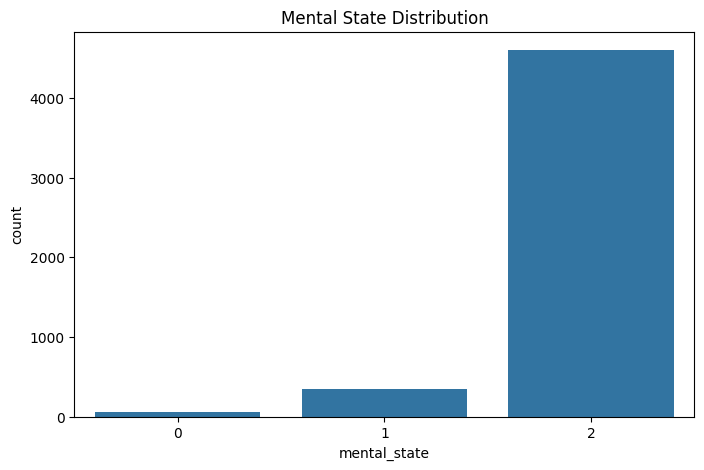

In [21]:
plt.figure(figsize=(8,5))
sns.countplot(x='mental_state', data=df)
plt.title("Mental State Distribution")
plt.show()

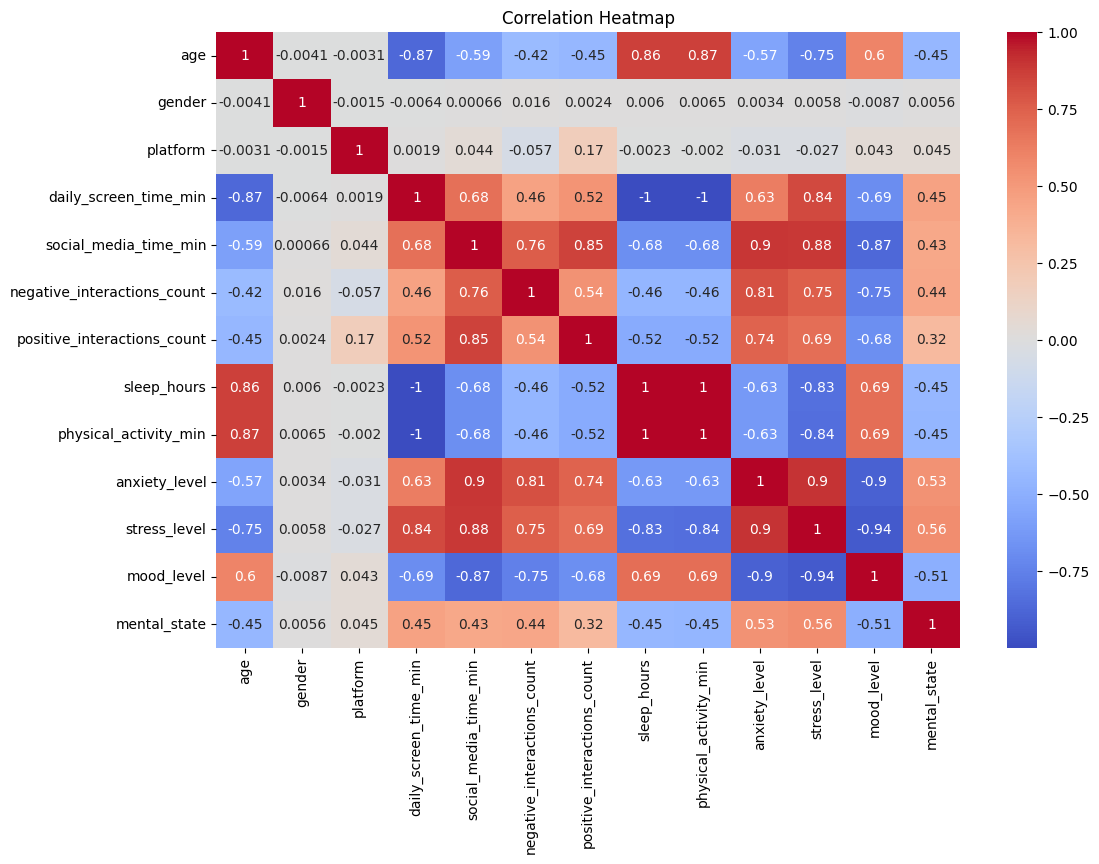

In [22]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

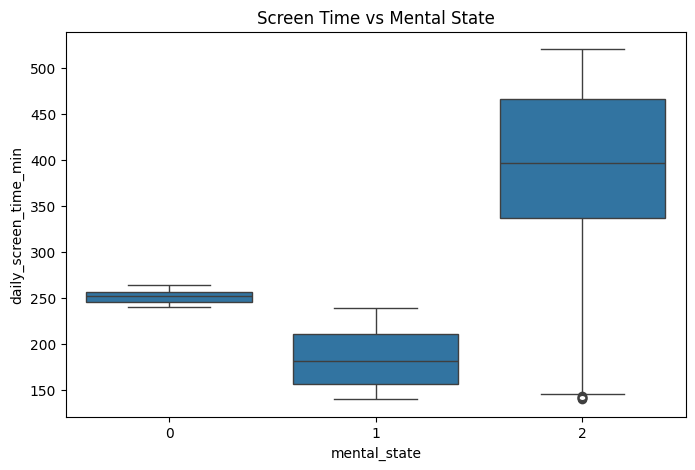

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(x='mental_state', y='daily_screen_time_min', data=df)
plt.title("Screen Time vs Mental State")
plt.show()

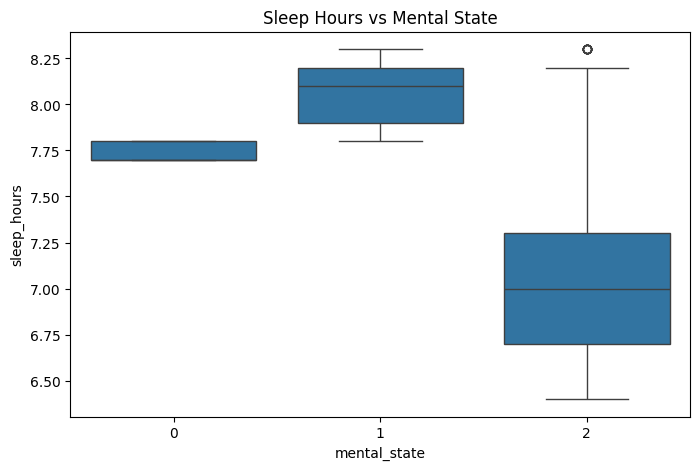

In [24]:
plt.figure(figsize=(8,5))
sns.boxplot(x='mental_state', y='sleep_hours', data=df)
plt.title("Sleep Hours vs Mental State")
plt.show()

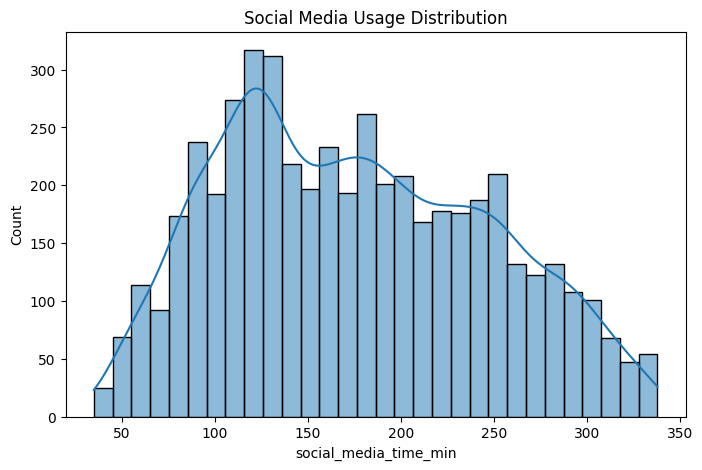

In [25]:
plt.figure(figsize=(8,5))
sns.histplot(df['social_media_time_min'], bins=30, kde=True)
plt.title("Social Media Usage Distribution")
plt.show()

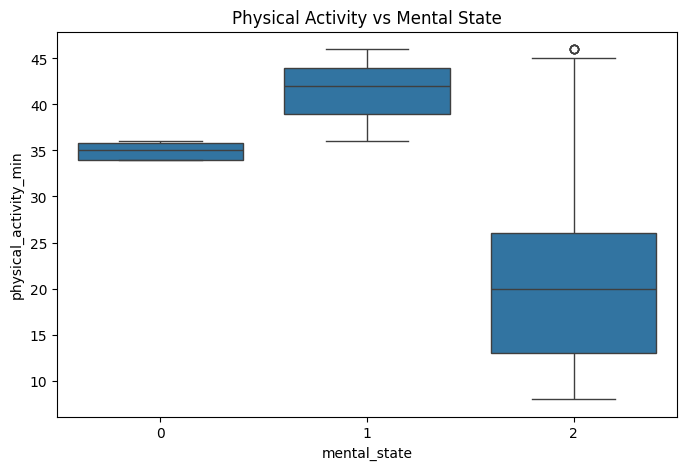

In [26]:
plt.figure(figsize=(8,5))
sns.boxplot(x='mental_state', y='physical_activity_min', data=df)
plt.title("Physical Activity vs Mental State")
plt.show()

In [49]:
#SPLITTING DATA INTO FEATURES & TARGET
X = df.drop([
    'mental_state',
    'anxiety_level',
    'stress_level',
    'mood_level'
], axis=1)
y=df['mental_state']

In [50]:
#TRAIN-TEST SPLIT
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [51]:
#verify split sizes
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(4000, 9)
(1000, 9)
(4000,)
(1000,)


In [36]:
!pip install imbalanced-learn #install imbalanced library

In [52]:
from imblearn.over_sampling import SMOTE
#apply SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [53]:
print(y_train.value_counts())  #verify balanced classes

mental_state
2    3686
1     268
0      46
Name: count, dtype: int64


In [54]:
print(y_train_smote.value_counts()) #balancing after applying smote

mental_state
2    3686
1    3686
0    3686
Name: count, dtype: int64


In [55]:
#TRAIN LOGISTIC REGRESSION MODEL
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_smote, y_train_smote)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [56]:
#MAKE PREDICTION
y_pred_lr=lr_model.predict(X_test)

In [60]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_lr))



Accuracy: 0.982


In [61]:
#CLASSIFICATION REPORT
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.52      1.00      0.69        12
           1       0.91      0.99      0.95        73
           2       1.00      0.98      0.99       915

    accuracy                           0.98      1000
   macro avg       0.81      0.99      0.87      1000
weighted avg       0.99      0.98      0.98      1000



In [62]:
#CONFUSION MATRIX
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

print(cm)

[[ 12   0   0]
 [  1  72   0]
 [ 10   7 898]]


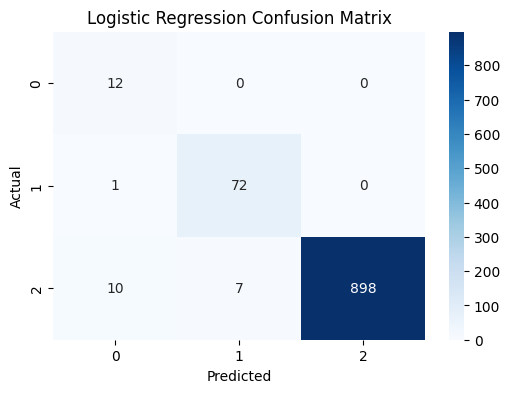

In [63]:
#VISUALIZE CONFUSION MATRIX
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [64]:
#TRAIN DECISION TREE
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train_smote, y_train_smote)

DecisionTreeClassifier(random_state=42)

In [65]:
#PREDICTION USING DECISION TREE
y_pred_dt = dt_model.predict(X_test)

In [66]:
#EVALUATE DECISION TREE
print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt))

print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        73
           2       1.00      1.00      1.00       915

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [67]:
#CONFUSION MATRIX
cm_dt = confusion_matrix(y_test, y_pred_dt)

print(cm_dt)

[[ 12   0   0]
 [  0  73   0]
 [  0   0 915]]


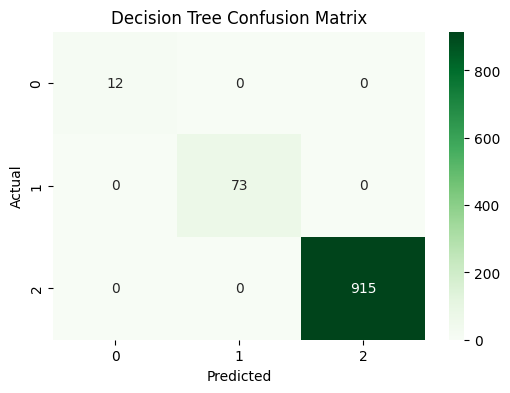

In [68]:
#VISUALIZE DT CONFUSION MATRIX
plt.figure(figsize=(6,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [69]:
#RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_smote, y_train_smote)

RandomForestClassifier(random_state=42)

In [70]:
#PREDICT USING RANDOM FOREST
y_pred_rf = rf_model.predict(X_test)

In [71]:
#EVALUATE RANDOM FOREST
print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        73
           2       1.00      1.00      1.00       915

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [72]:
#RANDOM FOREST CONFUSION MATRIX
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[ 12   0   0]
 [  0  73   0]
 [  0   0 915]]


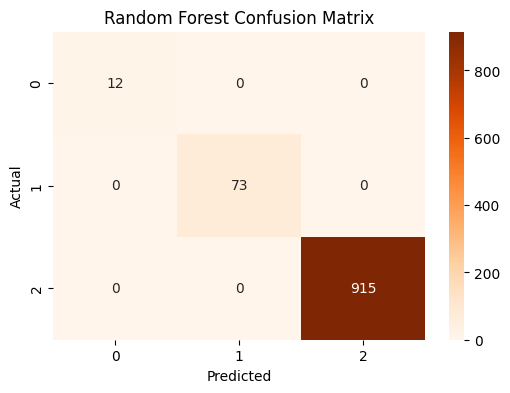

In [74]:
#VISUALIZE RF MATRIX
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [75]:
#MODEL COMPARSION
models = ['Logistic Regression',
          'Decision Tree',
          'Random Forest']

accuracies = [
    lr_accuracy,
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf)
]

comparison_df = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracies
})

print(comparison_df)

                 Model  Accuracy
0  Logistic Regression     0.982
1        Decision Tree     1.000
2        Random Forest     1.000


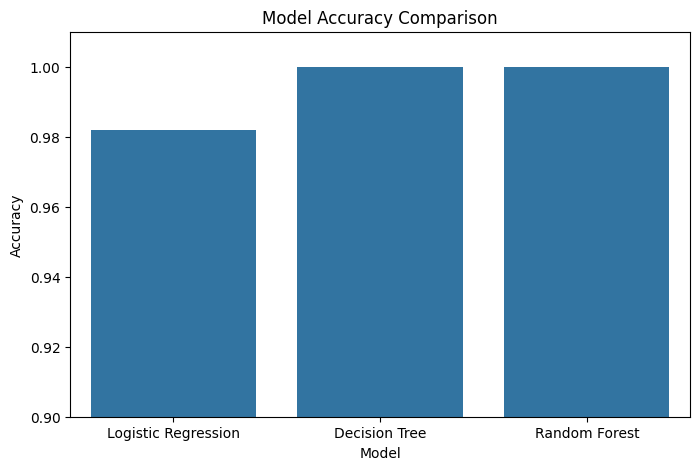

In [76]:
#VISUALIZATION OF MODEL COMPARSION
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=comparison_df
)

plt.title("Model Accuracy Comparison")
plt.ylim(0.9, 1.01)

plt.show()

In [78]:
#feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance =feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                       Feature  Importance
3        daily_screen_time_min    0.298473
4        social_media_time_min    0.276148
8        physical_activity_min    0.164181
7                  sleep_hours    0.110435
5  negative_interactions_count    0.071663
0                          age    0.063633
6  positive_interactions_count    0.011832
2                     platform    0.003414
1                       gender    0.000220


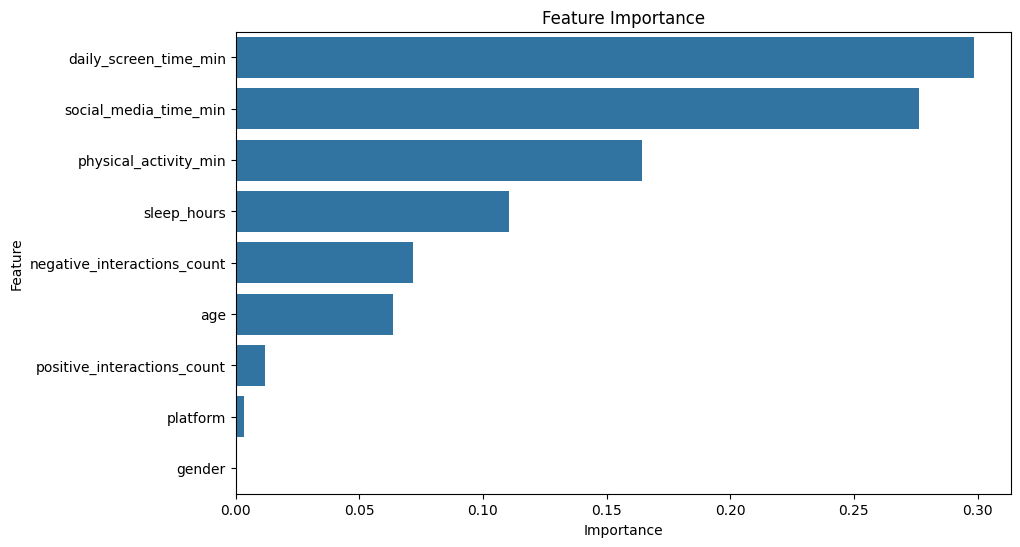

In [79]:
#Visualize feature importance
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance")
plt.show()

In [81]:
"""
For manual predictions
sample_prediction2 = rf_model.predict([
    [25, 0, 1, 120, 60, 0, 4, 8.0, 45]
])

print(sample_prediction2)

[1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [83]:
"""
for manual predictions
sample_prediction = rf_model.predict([
    [25, 1, 2, 500, 300, 2, 0, 5.5, 5]
])

print(sample_prediction)
"""

'\nfor manual predictions\nsample_prediction = rf_model.predict([\n    [25, 1, 2, 500, 300, 2, 0, 5.5, 5]\n])\n\nprint(sample_prediction)\n'

In [84]:
import joblib

joblib.dump(rf_model, 'mental_health_model.pkl')

['mental_health_model.pkl']

In [85]:
from google.colab import files

files.download('mental_health_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>